Metode Resnet

In [ ]:
# 🔥 Langkah 1: Import Library yang Dibutuhkan
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [ ]:
# 🔥 Langkah 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 🔥 Langkah 3: Path Dataset
dataset_path = '/content/drive/MyDrive/BDA/Dataset/Arsitektur'

In [ ]:
# Validasi path folder
if os.path.exists(dataset_path):
    print(f"Path ditemukan: {dataset_path}")
    print(f"Subfolder: {os.listdir(dataset_path)}")
else:
    print(f"Path TIDAK ditemukan: {dataset_path}")
    raise FileNotFoundError("Folder dataset tidak ditemukan!")

Path ditemukan: /content/drive/MyDrive/BDA/Dataset/Arsitektur
Subfolder: ['Modern', 'Tradisional', 'Kontemporer', 'Klasik', 'Kolonial']


In [ ]:
# 🔥 Langkah 4: Data Augmentation dan Preprocessing
image_size = (150, 150)  # Ukuran gambar

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,  # 20% untuk validasi
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=image_size,
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=image_size,
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 1938 images belonging to 5 classes.
Found 482 images belonging to 5 classes.


In [ ]:
# 🔥 Langkah 5: Membuat Model ResNet50
# Load ResNet50 dengan bobot dari imagenet dan exclude fully connected layer (include_top=False)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze semua layer dari ResNet50
for layer in base_model.layers:
    layer.trainable = False

# Tambahkan fully connected layer di atas ResNet
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
predictions = Dense(5, activation='softmax')(x)  # 5 kategori: Klasik, Modern, dll

# Buat model final
model = Model(inputs=base_model.input, outputs=predictions)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 🔥 Langkah 6: Kompilasi Model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
# 🔥 Langkah 7: Training Model
history = model.fit(
    train_generator,
    epochs=20,  # Jumlah epoch bisa diubah
    validation_data=val_generator
)

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 7/61 ━━━━━━━━━━━━━━━━━━━━ 7:49 9s/step - accuracy: 0.1359 - loss: 1.6829

/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


61/61 ━━━━━━━━━━━━━━━━━━━━ 676s 10s/step - accuracy: 0.1938 - loss: 1.6406 - val_accuracy: 0.2718 - val_loss: 1.6209
Epoch 2/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 277s 4s/step - accuracy: 0.2534 - loss: 1.5962 - val_accuracy: 0.2158 - val_loss: 1.5988
Epoch 3/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 264s 4s/step - accuracy: 0.2598 - loss: 1.5872 - val_accuracy: 0.2075 - val_loss: 1.5929
Epoch 4/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 256s 4s/step - accuracy: 0.2564 - loss: 1.5754 - val_accuracy: 0.2407 - val_loss: 1.5992
Epoch 5/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 287s 5s/step - accuracy: 0.2644 - loss: 1.5711 - val_accuracy: 0.2469 - val_loss: 1.5937
Epoch 6/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 255s 4s/step - accuracy: 0.2926 - loss: 1.5486 - val_accuracy: 0.2697 - val_loss: 1.5800
Epoch 7/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 255s 4s/step - accuracy: 0.3029 - loss: 1.5452 - val_accuracy: 0.2614 - val_loss: 1.5886
Epoch 8/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 263s 4s/step - accuracy: 0.2929 - loss: 1.5345 - val_accuracy: 0.2427 - val_loss: 1

In [ ]:
# 🔥 Langkah 8: Simpan Model
model_path = '/content/drive/MyDrive/BDA/Dataset/Arsitektur/resnet.h5'
model.save(model_path)
print(f"Model disimpan di: {model_path}")

Model disimpan di: /content/drive/MyDrive/BDA/Dataset/Arsitektur/resnet.h5


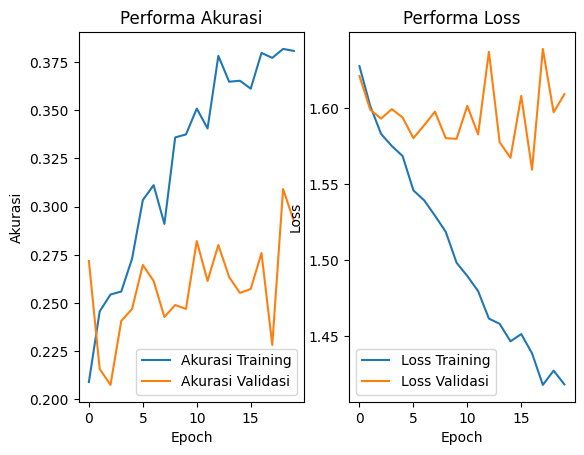

In [ ]:
# Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Akurasi Training')
plt.plot(history.history['val_accuracy'], label='Akurasi Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.title('Performa Akurasi')

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss Training')
plt.plot(history.history['val_loss'], label='Loss Validasi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Performa Loss')

plt.show()


Testing

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 🔥 Langkah 1: Load Model
model_path = '/content/drive/MyDrive/BDA/Dataset/Arsitektur/resnet.h5'
model = load_model(model_path)

In [ ]:
# 🔥 Langkah 2: Load Gambar Baru
image_path = '/content/drive/MyDrive/BDA/Dataset/Arsitektur/Klasik/Image_2.jpg'
image_size = (150, 150)
img = load_img(image_path, target_size=image_size)
img_array = img_to_array(img) / 255.0  # Normalisasi
img_array = np.expand_dims(img_array, axis=0)  # Tambahkan batch dimension

In [ ]:
# 🔥 Langkah 3: Prediksi Gambar
prediction = model.predict(img_array)
class_names = ['Klasik', 'Modern', 'Kontemporer', 'Tradisional', 'Kolonial']
predicted_class = class_names[np.argmax(prediction)]
print(f"Prediksi Gambar Ini: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Prediksi Gambar Ini: Klasik


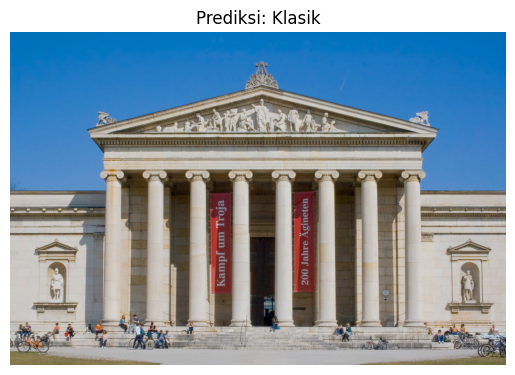

In [ ]:
# 🔥 Tampilkan Gambar dengan Keterangan
plt.imshow(load_img(image_path))
plt.title(f"Prediksi: {predicted_class}")
plt.axis('off')
plt.show()

In [ ]:
# 🔥 Langkah 2: Load Gambar Baru
image_path = '/content/drive/MyDrive/BDA/Dataset/Arsitektur/Tradisional/Image_2.jpg'
image_size = (150, 150)
img = load_img(image_path, target_size=image_size)
img_array = img_to_array(img) / 255.0  # Normalisasi
img_array = np.expand_dims(img_array, axis=0)  # Tambahkan batch dimension

In [ ]:
# 🔥 Langkah 3: Prediksi Gambar
prediction = model.predict(img_array)
class_names = ['Klasik', 'Modern', 'Kontemporer', 'Tradisional', 'Kolonial']
predicted_class = class_names[np.argmax(prediction)]
print(f"Prediksi Gambar Ini: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Prediksi Gambar Ini: Tradisional


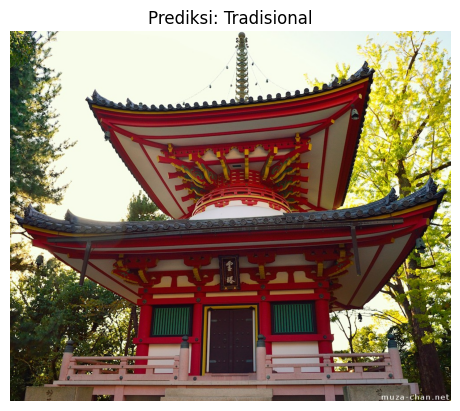

In [ ]:
# 🔥 Tampilkan Gambar dengan Keterangan
plt.imshow(load_img(image_path))
plt.title(f"Prediksi: {predicted_class}")
plt.axis('off')
plt.show()